In [1]:
import pyodbc
import pandas as pd

# Connect to SQL Server
conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=.;'
    'DATABASE=NBA_Analytics;'
    'Trusted_Connection=yes;'
)

print("Connected successfully!")

Connected successfully!


In [3]:
with open('../Queries/Position Performance Analysis.sql', 'r') as file:
    query_q1 = file.read()

df_q1 = pd.read_sql(query_q1, conn)
print(df_q1)

C:\Users\PC\AppData\Local\Temp\ipykernel_26484\1440664030.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q1 = pd.read_sql(query_q1, conn)


  Pos  player_count  avg_points  avg_rebounds  avg_assists  avg_steals  \
0  PG            79        11.6           3.0          4.3         0.8   
1  PF            89        10.5           4.5          2.0         0.6   
2  SG           100        10.2           2.8          2.4         0.7   
3   C            83         9.3           6.1          1.7         0.6   
4  SF            95         9.1           3.4          1.7         0.7   

   avg_blocks  
0         0.3  
1         0.5  
2         0.3  
3         0.9  
4         0.4  


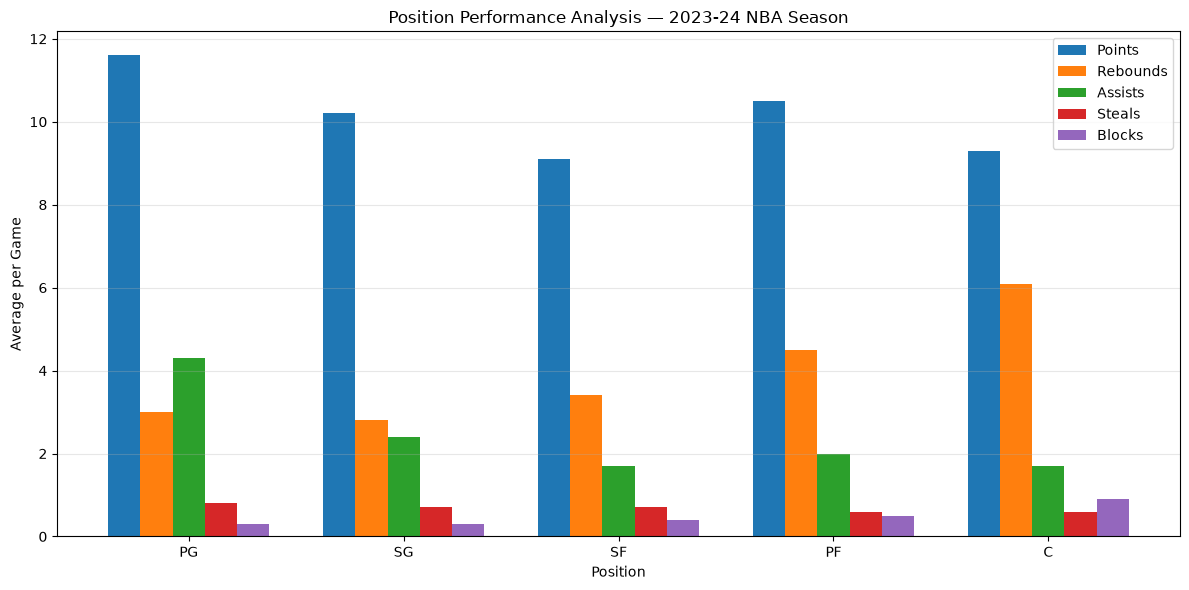

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Set position order logically (offense to defense flow)
df_q1 = df_q1.set_index('Pos').loc[['PG', 'SG', 'SF', 'PF', 'C']].reset_index()

stats = ['avg_points', 'avg_rebounds', 'avg_assists', 'avg_steals', 'avg_blocks']
labels = ['Points', 'Rebounds', 'Assists', 'Steals', 'Blocks']

x = np.arange(len(df_q1['Pos']))
width = 0.15

fig, ax = plt.subplots(figsize=(12, 6))

for i, (stat, label) in enumerate(zip(stats, labels)):
    ax.bar(x + i*width, df_q1[stat], width, label=label)

ax.set_xlabel('Position')
ax.set_ylabel('Average per Game')
ax.set_title('Position Performance Analysis — 2023-24 NBA Season')
ax.set_xticks(x + width*2)
ax.set_xticklabels(df_q1['Pos'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../Visualisation/q1_position_dominance.png', dpi=150)
plt.show()

In [8]:
with open('../Queries/Team Offensive Output Analysis.sql', 'r') as file:
    query_q2 = file.read()

df_q2 = pd.read_sql(query_q2, conn)
print(df_q2)

   Team  Total Score  Total Assists  Avg Shooting Efficiency
0   TOR          223             58                     0.47
1   CHO          197             54                     0.45
2   PHI          188             42                     0.45
3   MEM          182             45                     0.45
4   NYK          180             34                     0.45
5   POR          176             39                     0.44
6   DET          173             38                     0.45
7   DAL          169             36                     0.49
8   MIA          164             39                     0.47
9   IND          163             40                     0.51
10  UTA          163             37                     0.47
11  ATL          157             36                     0.46
12  WAS          156             38                     0.47
13  PHO          155             36                     0.47
14  BRK          151             36                     0.46
15  BOS          149    

C:\Users\PC\AppData\Local\Temp\ipykernel_26484\1451911927.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q2 = pd.read_sql(query_q2, conn)


In [20]:
NBA_BLUE = '#1d428a'
NBA_RED = '#c8102e'
NBA_GOLD = '#fdb927'  # accent/highlight color
NBA_GRAY = '#cccccc'  # neutral/background bars

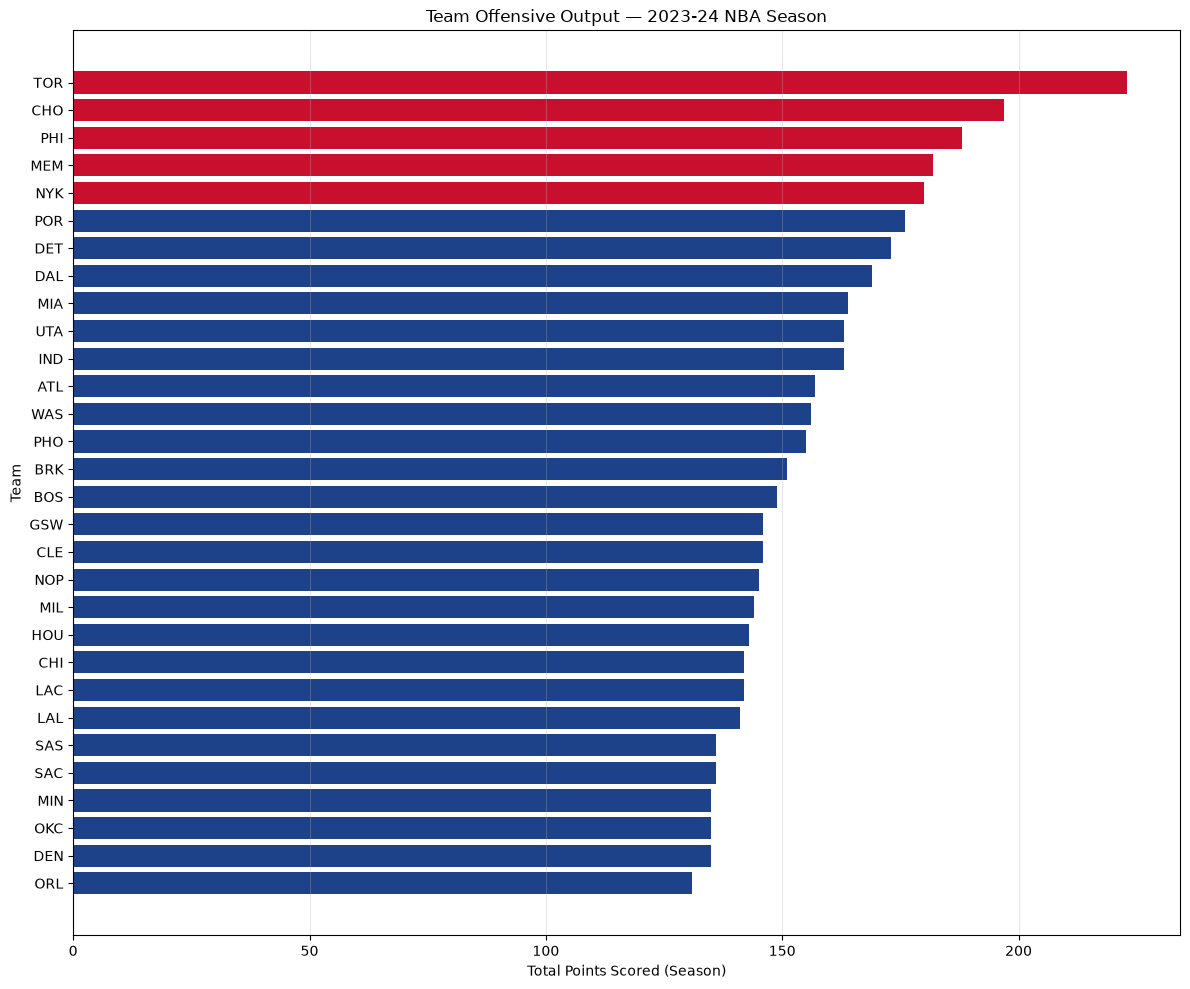

In [22]:

import matplotlib.colors as mcolors
df_q2 = df_q2.sort_values(by='Total Score', ascending=True)
colors = [NBA_RED if i >= len(df_q2)-5 else NBA_BLUE for i in range(len(df_q2))]

plt.figure(figsize=(12, 10))
plt.barh(df_q2['Team'], df_q2['Total Score'], color=colors)

plt.xlabel('Total Points Scored (Season)')
plt.ylabel('Team')
plt.title('Team Offensive Output — 2023-24 NBA Season')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../Visualisation/q2_team_offensive_output.png', dpi=150)
plt.show()